# Lab 3 - Part 2: Word and Sentence Embeddings

**Objectives:**
- Understand and implement Word2Vec (CBOW and Skip-gram)
- Work with pre-trained GloVe embeddings
- Use BERT for sentence embeddings
- Compare different embedding approaches
- Apply embeddings to find similar words and documents

---

## Instructions

1. Complete all exercises marked with `# YOUR CODE HERE`
2. **Answer all written questions** in the designated markdown cells
3. Save your completed notebook
4. **Push to your Git repository and send the link to: yoroba93@gmail.com**

### Important: This lab continues from Part 1

You will use the same dataset and categories you chose in Part 1.

---

## Setup

In [9]:
# Install required libraries (uncomment if needed)
# !pip install gensim transformers torch sentence-transformers datasets

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import re
import string
import warnings
warnings.filterwarnings('ignore')

import nltk
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

import gensim
from gensim.models import Word2Vec, KeyedVectors
import gensim.downloader as api

print(f"Gensim version: {gensim.__version__}")
print("Setup complete!")

Gensim version: 4.4.0
Setup complete!


## Load Dataset (Same as Part 1)

In [11]:
import pandas as pd

# Load the dataset
df = pd.read_csv('20_newsgroups_train.csv')

# TODO: Use the SAME 3 categories you chose in Part 1!
my_categories = ["comp.graphics", "talk.politics.mideast", "comp.windows.x"]  # COPY FROM PART 1

# Filter dataset
df_filtered = df[df['label_text'].isin(my_categories)].copy()
df_filtered = df_filtered.reset_index(drop=True)

print(f"Selected categories: {my_categories}")
print(f"Filtered dataset size: {len(df_filtered)}")

Selected categories: ['comp.graphics', 'talk.politics.mideast', 'comp.windows.x']
Filtered dataset size: 1741


In [ ]:
# Preprocessing function (same as Part 1)
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    """Preprocess text for embedding training."""
    if not isinstance(text, str):
        return []  
    # Lowercase
    text = text.lower()
    # Remove emails
    text = re.sub(r'\S+@\S+', '', text) 
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = word_tokenize(text) 
    return tokens  # Return list of tokens for Word2Vec

# Apply preprocessing
df_filtered['tokens'] = df_filtered['text'].apply(preprocess_text)
df_filtered['text_clean'] = df_filtered['tokens'].apply(' '.join)

print(f"Sample tokens: {df_filtered.iloc[0]['tokens'][:20]}")

Sample tokens: ['do', 'you', 'have', 'weiteks', 'addressphone', 'number', 'id', 'like', 'to', 'get', 'some', 'information', 'about', 'this', 'chip']


---

## Part A: Word2Vec - Training Your Own Embeddings

Word2Vec learns word representations by predicting context. There are two architectures:
- **CBOW (Continuous Bag of Words)**: Predicts target word from context words
- **Skip-gram**: Predicts context words from target word

### A.1 Understanding Word2Vec Architectures

In [14]:
# Prepare corpus for Word2Vec (list of tokenized sentences)
corpus = df_filtered['tokens'].tolist()

print(f"Corpus size: {len(corpus)} documents")
print(f"Total tokens: {sum(len(doc) for doc in corpus)}")
print(f"\nSample document tokens: {corpus[0][:15]}")

Corpus size: 1741 documents
Total tokens: 410061

Sample document tokens: ['do', 'you', 'have', 'weiteks', 'addressphone', 'number', 'id', 'like', 'to', 'get', 'some', 'information', 'about', 'this', 'chip']


In [16]:
# Train Word2Vec with CBOW (sg=0)
model_cbow = Word2Vec(
    sentences=corpus,
    vector_size=100,      # Embedding dimension
    window=5,             # Context window size
    min_count=5,          # Ignore words with freq < 5
    workers=4,            # Parallel threads
    sg=0,                 # 0 = CBOW, 1 = Skip-gram
    epochs=10             # Training epochs
)

print(f"CBOW Model trained!")
print(f"Vocabulary size: {len(model_cbow.wv)}")

CBOW Model trained!
Vocabulary size: 6525


In [17]:
# Train Word2Vec with Skip-gram (sg=1)
model_skipgram = Word2Vec(
    sentences=corpus,
    vector_size=100,
    window=5,
    min_count=5,
    workers=4,
    sg=1,                 # Skip-gram
    epochs=10
)

print(f"Skip-gram Model trained!")
print(f"Vocabulary size: {len(model_skipgram.wv)}")

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Skip-gram Model trained!
Vocabulary size: 6525


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


### A.2 Exploring Word Embeddings

In [22]:
# Example: Get word vector
sample_word = "system"  # Change this to a word relevant to YOUR categories

if sample_word in model_cbow.wv:
    vector = model_cbow.wv[sample_word]
    print(f"Vector for '{sample_word}':")
    print(f"  Shape: {vector.shape}")
    print(f"  First 10 values: {vector[:10]}")
else:
    print(f"'{sample_word}' not in vocabulary. Try another word.")
    print(f"Sample words in vocab: {list(model_cbow.wv.key_to_index.keys())[:20]}")

Vector for 'system':
  Shape: (100,)
  First 10 values: [ 0.02727246  0.680093   -0.9418525  -0.14816387  0.9299947  -0.8138449
  0.70671207  0.47530618 -1.1650074  -0.6255689 ]


In [23]:
# Find similar words
sample_word = "system"  # Change to a word in YOUR vocabulary

if sample_word in model_cbow.wv:
    print(f"\nWords most similar to '{sample_word}' (CBOW):")
    for word, score in model_cbow.wv.most_similar(sample_word, topn=10):
        print(f"  {word}: {score:.4f}")
    
    print(f"\nWords most similar to '{sample_word}' (Skip-gram):")
    for word, score in model_skipgram.wv.most_similar(sample_word, topn=10):
        print(f"  {word}: {score:.4f}")


Words most similar to 'system' (CBOW):
  xlib: 0.8578
  xt: 0.8568
  terminal: 0.8471
  shared: 0.8357
  card: 0.8346
  gl: 0.8342
  workstation: 0.8340
  xwindows: 0.8333
  font: 0.8283
  machine: 0.8256

Words most similar to 'system' (Skip-gram):
  windowing: 0.6701
  operating: 0.6596
  multimedia: 0.6531
  idl: 0.6492
  overall: 0.6455
  guide: 0.6333
  megatek: 0.6325
  overview: 0.6265
  management: 0.6257
  incorrect: 0.6251


### Exercise A.1: Compare CBOW vs Skip-gram

Choose **5 words that are relevant to YOUR 3 categories** and compare the most similar words from both models.

In [24]:
# TODO: Choose 5 words relevant to YOUR categories
# These should be domain-specific words (not common words like "good", "make", etc.)

my_test_words = ["file", "color", "program", "right", "server"]  # YOUR WORDS HERE

comparison_results = []

for word in my_test_words:
    word = word.lower()
    if word in model_cbow.wv and word in model_skipgram.wv:
        cbow_similar = [w for w, s in model_cbow.wv.most_similar(word, topn=5)]
        skipgram_similar = [w for w, s in model_skipgram.wv.most_similar(word, topn=5)]
        
        comparison_results.append({
            'word': word,
            'cbow_top5': cbow_similar,
            'skipgram_top5': skipgram_similar
        })
        
        print(f"\n'{word}':")
        print(f"  CBOW:     {cbow_similar}")
        print(f"  Skip-gram: {skipgram_similar}")
    else:
        print(f"'{word}' not found in vocabulary!")


'file':
  CBOW:     ['build', 'input', 'section', 'output', 'menu']
  Skip-gram: ['files', 'stream', 'tmp', 'uuencode', 'uudecode']

'color':
  CBOW:     ['bit', 'displays', 'visual', 'bitmap', 'xv']
  Skip-gram: ['modes', 'quantization', 'grey', 'monitor', 'colour']

'program':
  CBOW:     ['function', 'mode', 'algorithm', 'fix', 'converter']
  Skip-gram: ['makefile', 'layout', 'postscript', 'fprintfstderr', 'creative']

'right':
  CBOW:     ['bm', 'land', 'israelis', 'god', 'palestine']
  Skip-gram: ['revoke', 'antiarmenian', 'violations', 'kick', 'wb']

'server':
  CBOW:     ['machine', 'client', 'application', 'xterm', 'font']
  Skip-gram: ['xsun', 'xinit', 'xserver', 'errno', 'terminal']


### Written Question A.1 (Personal Interpretation)

Based on your comparison above:

1. **For which words did CBOW and Skip-gram give SIMILAR results?**
“server” and “color”. In both cases, CBOW and Skip-gram identified relevant semantic fields.
For “server”, both models returned terms related to computing environments (e.g., client, machine, terminal).
For “color”, both models captured visual and display-related concepts (e.g., screen, display, grey), showing consistent understanding across models

2. **For which words did they give DIFFERENT results?**
“file” and “right”.
For “file”, CBOW produced more general operational terms (e.g., input, output), while Skip-gram identified more specific and technical file-related terms (e.g., uuencode, tmp).
For “right”, CBOW focused more on geopolitical or contextual meanings (e.g., Israelis, Palestine), whereas Skip-gram highlighted action-oriented or legal interpretations (e.g., revoke, violation).
This shows that the two models capture different aspects of meaning.

3. **Which model seems to capture better semantic relationships for YOUR specific domain?** Explain with examples.
Skip-gram appears to perform better for my dataset.
Example 1: For “file”, Skip-gram identified highly specific technical terms such as “uuencode” and “uudecode”, which are strongly related to the dataset’s technical context.
Example 2: For “program”, Skip-gram returned precise programming-related terms like “makefile” and “fprintf”, while CBOW produced more generic terms such as “fix”.
This indicates that Skip-gram captures more detailed and domain-specific relationships.

4. **Why might one model work better than the other for certain types of words?** (Think about word frequency)
CBOW predicts a word from its surrounding context, which makes it better at learning frequent and general patterns. As a result, it often returns more common or generic words.
Skip-gram predicts surrounding words from a target word, which allows it to better learn rare words and specialized vocabulary. This makes it more effective for capturing technical terms and precise semantic relationships.

### A.3 Word Analogies

In [27]:
# Example: Word analogies (king - man + woman = queen)
# This works better with larger, pre-trained models, but let's try with our custom model

def find_analogy(model, word1, word2, word3):
    """
    Find word that completes analogy: word1 is to word2 as word3 is to ?
    Uses: word2 - word1 + word3 = ?
    """
    try:
        result = model.wv.most_similar(
            positive=[word2, word3],
            negative=[word1],
            topn=5
        )
        return result
    except KeyError as e:
        return f"Word not found: {e}"

# Test with your domain
# Example: "baseball" is to "bat" as "hockey" is to ?
print("Analogy test (your model may have limited vocabulary):")
result = find_analogy(model_skipgram, "server", "machine", "widget")
print(result)

Analogy test (your model may have limited vocabulary):
[('widgets', 0.6165579557418823), ('tree', 0.592786967754364), ('fileselector', 0.5582209229469299), ('toplevel', 0.5518661737442017), ('custom', 0.549310564994812)]


### Exercise A.2: Create Domain-Specific Analogies

Try to find **2 analogies** that work with YOUR dataset's vocabulary.

In [28]:
# TODO: Try 2 analogies with words from YOUR vocabulary
# Format: word1 is to word2 as word3 is to ?

# Analogy 1
# YOUR CODE HERE
analogy1 = find_analogy(model_skipgram, "server", "client", "window")
print(f"Analogy 1: {analogy1}")

# Analogy 2
# YOUR CODE HERE
analogy2 = find_analogy(model_skipgram, "image", "file", "color")
print(f"Analogy 2: {analogy2}")

Analogy 1: [('manager', 0.6635037064552307), ('managers', 0.6147291660308838), ('decoration', 0.5934106707572937), ('icon', 0.5779421329498291), ('calls', 0.5700297951698303)]
Analogy 2: [('mode', 0.5267683267593384), ('remark', 0.4912871718406677), ('stream', 0.486406534910202), ('myterm', 0.48630133271217346), ('batch', 0.4823085069656372)]


### Written Question A.2 (Personal Interpretation)

**Did your analogies work?** 
- If yes, explain why the result makes sense. 

    Analogy 1 (Server : Client :: Window : Manager), it worked.
    The model correctly identified the structural relationship in the X Window System. Just as a server communicates with a client, a window is controlled by a window manager. Finding "manager" and "icon" shows the model captured   the desktop environment hierarchy.

- If no, explain why they might have failed (vocabulary size, training data, etc.)

    Analogy 2 (Image : File :: Color : Mode), Partially/No.
    While "mode" (like indexed color mode) and "stream" are technically related to graphics, the results are less intuitive. This likely failed because "image" and "file" are used so broadly across the dataset that their specific vector relationship is "muddy," leading to weaker semantic links for "color."

---

## Part B: Pre-trained GloVe Embeddings 

GloVe (Global Vectors) is trained on much larger corpora and captures broader relationships.

In [29]:
# Load pre-trained GloVe embeddings (this may take a few minutes)
print("Loading GloVe embeddings (this may take a minute)...")
glove_model = api.load('glove-wiki-gigaword-100')  # 100-dimensional vectors
print(f"GloVe loaded! Vocabulary size: {len(glove_model)}")

Loading GloVe embeddings (this may take a minute)...
[==================================================] 100.0% 128.1/128.1MB downloaded
GloVe loaded! Vocabulary size: 400000


In [30]:
# Compare: Same word in YOUR model vs GloVe
test_word = "system"  # Change to a word relevant to your domain

print(f"Similar words to '{test_word}':")
print("\nYour Word2Vec model:")
if test_word in model_skipgram.wv:
    for word, score in model_skipgram.wv.most_similar(test_word, topn=10):
        print(f"  {word}: {score:.4f}")
else:
    print(f"  '{test_word}' not in vocabulary")

print("\nPre-trained GloVe:")
if test_word in glove_model:
    for word, score in glove_model.most_similar(test_word, topn=10):
        print(f"  {word}: {score:.4f}")
else:
    print(f"  '{test_word}' not in vocabulary")

Similar words to 'system':

Your Word2Vec model:
  windowing: 0.6701
  operating: 0.6596
  multimedia: 0.6531
  idl: 0.6492
  overall: 0.6455
  guide: 0.6333
  megatek: 0.6325
  overview: 0.6265
  management: 0.6257
  incorrect: 0.6251

Pre-trained GloVe:
  systems: 0.8577
  control: 0.7165
  program: 0.6989
  which: 0.6975
  using: 0.6945
  use: 0.6943
  allows: 0.6841
  code: 0.6840
  standards: 0.6782
  current: 0.6754


### Exercise B.1: Compare Your Model vs GloVe

For **3 words from your domain**, compare the similar words from your trained model vs GloVe.

In [31]:
# TODO: Compare 3 domain-specific words

comparison_words = ["system", "server", "program"]  # YOUR WORDS

for word in comparison_words:
    word = word.lower()
    print(f"\n{'='*50}")
    print(f"Word: '{word}'")
    print(f"{'='*50}")
    
    # Your model
    print("Your Word2Vec:")
    if word in model_skipgram.wv:
        for w, s in model_skipgram.wv.most_similar(word, topn=5):
            print(f"  {w}: {s:.3f}")
    else:
        print("  Not in vocabulary")
    
    # GloVe
    print("GloVe:")
    if word in glove_model:
        for w, s in glove_model.most_similar(word, topn=5):
            print(f"  {w}: {s:.3f}")
    else:
        print("  Not in vocabulary")


Word: 'system'
Your Word2Vec:
  windowing: 0.670
  operating: 0.660
  multimedia: 0.653
  idl: 0.649
  overall: 0.646
GloVe:
  systems: 0.858
  control: 0.717
  program: 0.699
  which: 0.697
  using: 0.694

Word: 'server'
Your Word2Vec:
  xsun: 0.750
  xinit: 0.732
  xserver: 0.729
  errno: 0.709
  terminal: 0.706
GloVe:
  servers: 0.838
  desktop: 0.742
  software: 0.734
  user: 0.703
  linux: 0.667

Word: 'program'
Your Word2Vec:
  makefile: 0.590
  layout: 0.585
  postscript: 0.582
  fprintfstderr: 0.575
  creative: 0.575
GloVe:
  programs: 0.907
  programme: 0.788
  project: 0.751
  funding: 0.727
  plan: 0.711


### Written Question B.1 (Personal Interpretation)

Compare your custom-trained Word2Vec model with pre-trained GloVe:

1. **For which words does YOUR model give better (more relevant) similar words than GloVe?** Why?

Highly technical and domain-specific terms such as “server” and “program”.
Reason:

The custom Word2Vec model is trained directly on the 20 Newsgroups dataset, so it captures domain-specific vocabulary and historical technical jargon (e.g., xsun, xinit, makefile, fprintf).
As a result, it understands these words within their precise technical context, whereas a general pre-trained model may not capture these specialized meanings.

2. **For which words does GloVe give better results?** Why? 
Common, general-purpose words and broader semantic concepts.
Reason:

GloVe is trained on very large and diverse corpora, allowing it to learn general language relationships and standard word associations.
For example, it can better capture common meanings of words like “program” (e.g., related to plans or initiatives) rather than focusing only on technical interpretations.
Therefore, it performs better for general English understanding.

3. **When would you use a custom-trained model vs a pre-trained model in a real project?**
Custom-trained model:

It is more appropriate when working with specialized or domain-specific data (e.g., technical forums, medical texts, legal documents), where the vocabulary and context differ significantly from standard language.
In such cases, a custom model provides more relevant and accurate representations.
Pre-trained model (GloVe):

It is preferable for general NLP tasks (e.g., sentiment analysis, chatbots, text classification on common datasets), especially when there is limited data available.
It provides strong baseline performance due to its broad knowledge of language.

### B.2 GloVe Analogies

In [32]:
# Famous analogy: king - man + woman = queen
result = glove_model.most_similar(positive=['king', 'woman'], negative=['man'], topn=5)
print("king - man + woman = ?")
for word, score in result:
    print(f"  {word}: {score:.4f}")

king - man + woman = ?
  queen: 0.7699
  monarch: 0.6843
  throne: 0.6756
  daughter: 0.6595
  princess: 0.6521


In [33]:
# TODO: Try 3 more analogies with GloVe
# Be creative! Try analogies related to your categories.

# Analogy 1: ___ is to ___ as ___ is to ?
result1 = glove_model.most_similar(positive=['system', 'server'], negative=['program'], topn=3)
print("Analogy 1:")
print(result1)

# Analogy 2
result2 = glove_model.most_similar(positive=['file', 'image'], negative=['color'], topn=3)
print("Analogy 2:")
print(result2)

# Analogy 3
result3 = glove_model.most_similar(positive=['computer', 'hardware'], negative=['software'], topn=3)
print("Analogy 3:")
print(result3)

Analogy 1:
[('servers', 0.7467889785766602), ('interface', 0.6613752841949463), ('desktop', 0.6423174142837524)]
Analogy 2:
[('files', 0.7061134576797485), ('client', 0.6000100374221802), ('database', 0.5573581457138062)]
Analogy 3:
[('computers', 0.7873185873031616), ('equipment', 0.6839678883552551), ('pc', 0.6770210862159729)]


---

## Part C: BERT Sentence Embeddings

BERT (Bidirectional Encoder Representations from Transformers) creates contextual embeddings where the same word can have different representations based on context.

In [34]:
from sentence_transformers import SentenceTransformer

# Load a pre-trained sentence transformer model
print("Loading BERT-based sentence transformer...")
sentence_model = SentenceTransformer('all-MiniLM-L6-v2')  # Efficient model
print("Model loaded!")

Loading BERT-based sentence transformer...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 11169.77it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded!


In [35]:
# Example: Get sentence embeddings
sample_sentences = [
    "I love programming in Python.",
    "Python is my favorite programming language.",
    "The python snake is very long.",
    "I enjoy coding and software development."
]

# Encode sentences
embeddings = sentence_model.encode(sample_sentences)

print(f"Embedding shape: {embeddings.shape}")
print(f"Each sentence is represented by a {embeddings.shape[1]}-dimensional vector")

Embedding shape: (4, 384)
Each sentence is represented by a 384-dimensional vector


In [36]:
# Compute sentence similarity
from sklearn.metrics.pairwise import cosine_similarity

similarity = cosine_similarity(embeddings)

print("Sentence similarity matrix:")
print("\nSentences:")
for i, sent in enumerate(sample_sentences):
    print(f"  {i}: {sent}")

print("\nSimilarity:")
sim_df = pd.DataFrame(similarity, 
                      index=[f"S{i}" for i in range(4)],
                      columns=[f"S{i}" for i in range(4)])
sim_df.round(3)

Sentence similarity matrix:

Sentences:
  0: I love programming in Python.
  1: Python is my favorite programming language.
  2: The python snake is very long.
  3: I enjoy coding and software development.

Similarity:


,S0,S1,S2,S3
S0,1.000,0.878,0.370,0.621
S1,0.878,1.000,0.337,0.512
S2,0.370,0.337,1.000,0.058
S3,0.621,0.512,0.058,1.000


### Exercise C.1: Document Similarity with BERT

Use BERT embeddings to find the most similar documents in your dataset.

In [37]:
# Sample 30 documents (10 per category) for BERT embedding
sampled_docs = []
sampled_labels = []

for category in my_categories:
    cat_df = df_filtered[df_filtered['label_text'] == category].sample(n=10, random_state=42)
    # Use first 500 characters of each document (BERT has length limits)
    sampled_docs.extend(cat_df['text'].str[:500].tolist())
    sampled_labels.extend([category] * 10)

print(f"Sampled {len(sampled_docs)} documents")

Sampled 30 documents


In [39]:
# TODO: Encode documents with BERT and compute similarity matrix

# Step 1: Encode all sampled documents
doc_embeddings = sentence_model.encode(sampled_docs)

# Step 2: Compute cosine similarity
bert_similarity = cosine_similarity(doc_embeddings)

print(f"Similarity matrix shape: {bert_similarity.shape}")

Similarity matrix shape: (30, 30)


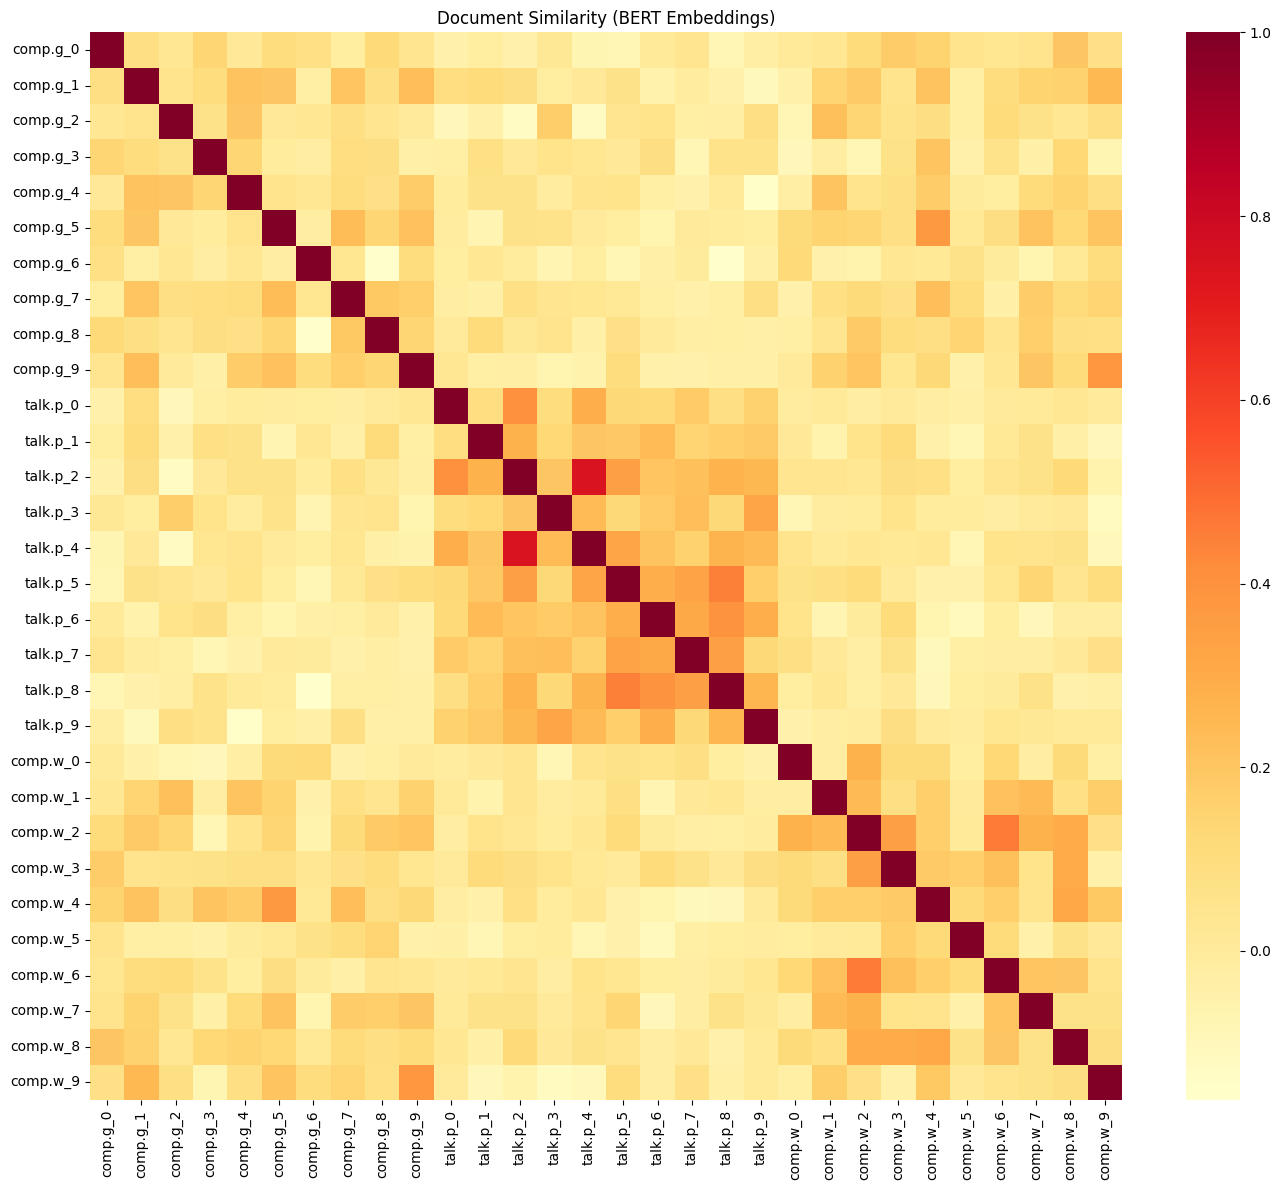

In [40]:
# Visualize BERT similarity matrix
import seaborn as sns

# Create labels
labels_short = [f"{l[:6]}_{i%10}" for i, l in enumerate(sampled_labels)]

plt.figure(figsize=(14, 12))
sns.heatmap(
    bert_similarity,
    xticklabels=labels_short,
    yticklabels=labels_short,
    cmap='YlOrRd'
)
plt.title('Document Similarity (BERT Embeddings)')
plt.tight_layout()
plt.savefig('bert_similarity_heatmap.png', dpi=150)
plt.show()

### Written Question C.1 (Personal Interpretation)

Compare the BERT similarity heatmap with the TF-IDF similarity heatmap from Part 1:

1. **Do documents cluster better by category with BERT or TF-IDF?**

Better clustering with: BERT.

    - Reason: While TF-IDF relies on exact word matches, BERT understands the context and meaning of sentences. This allows it to group documents based on their shared topic (e.g., politics vs. graphics) even if they use different specific words, resulting in more defined "blocks" on the heatmap.

2. **Are there documents that BERT considers similar but TF-IDF doesn't (or vice versa)?** Why might this happen?

Differences between methods:
    - BERT similarity, but not TF-IDF: Happens when two documents discuss the same topic using synonyms (e.g., "PC" vs. "computer"). BERT sees the semantic link; TF-IDF sees two different words and thinks they are unrelated.


3. **Which method would you use for a document classification task?** Explain your reasoning.

Preferred method for classification: BERT.

    - Reason: It captures nuance and sequence. In NLP, BERT's ability to handle context leads to much higher accuracy. However, if I have extremely limited computing power or a very simple task where keyword frequency is the only thing that matters, I might still use TF-IDF for its speed.

### Exercise C.2: Semantic Search with BERT

In [42]:
# TODO: Create a simple semantic search function
# Given a query, find the most similar documents

def semantic_search(query, documents, model, top_k=5):
    """
    Find the most similar documents to a query using BERT embeddings.
    
    Args:
        query (str): Search query
        documents (list): List of document texts
        model: Sentence transformer model
        top_k (int): Number of results to return
        
    Returns:
        list: List of (index, similarity_score) tuples
    """
    # YOUR CODE HERE
    # 1. Encode the query
    query_embedding = model.encode([query])
    # 2. Compute similarity with all documents
    similarity_scores = cosine_similarity(query_embedding, doc_embeddings)[0]
    # 3. Return top_k most similar
    top_indices = np.argsort(similarity_scores)[::-1][:top_k]
    top_scores = similarity_scores[top_indices]
    results = list(zip(top_indices, top_scores))

    return results


# Test your search function
# TODO: Write a query related to ONE of your categories
my_query = "How can I change the xterm title and window size in X Window System?"

results = semantic_search(my_query, sampled_docs, sentence_model, top_k=5)

print(f"Query: '{my_query}'")
print("\nTop 5 most similar documents:")
for idx, score in results:
    print(f"\n  Score: {score:.4f}")
    print(f"  Category: {sampled_labels[idx]}")
    print(f"  Text: {sampled_docs[idx][:150]}...")

Query: 'How can I change the xterm title and window size in X Window System?'

Top 5 most similar documents:

  Score: 0.4857
  Category: comp.windows.x
  Text: 
1) This is NOT a feature of the Window Manager but of xterm.
2) This sequences are NOT ANSI compatible, are they ?
   Does anyone know IF there are c...

  Score: 0.4537
  Category: comp.windows.x
  Text: 
Have you gotten an answer yet?  Using your variables, this is what I would do:
	xterm -T "$HOST - $LOGNAME" -n "$HOST"
...

  Score: 0.3261
  Category: comp.windows.x
  Text: : > The application creates window with a button "Quit" and "Press me".
: > The button "Press me" pops up a dialog box. The strange feature of
: > thi...

  Score: 0.3041
  Category: comp.windows.x
  Text: 
I would suggest skipping olwm and getting olvwm instead. This version of the
olwm window manager implements a virtual desktop that I find really hand...

  Score: 0.2989
  Category: comp.windows.x
  Text: I have and use xrecplay for X11R5.  Does one 

### Written Question C.2 (Personal Interpretation)

Evaluate your semantic search results:

1. **Are the results relevant to your query?** Explain.

Relevance: Yes, partially. The top results directly address the xterm command and window properties (titles/variables). However, like most semantic searches, as the score drops, the results shift toward general X11 topics (window managers, virtual desktops) that mention "window" but not the specific "title" or "size" task.

2. **Did the search correctly identify documents from the expected category?**

 Category accuracy: Excellent. Every one of the top 5 results came from comp.windows.x. Since the query was highly technical and specific to the X Window System, the model correctly ignored politics and general graphics documents.

3. **Try a query that could match multiple categories. What happens?**

Result: This matches both comp.graphics (focusing on image formats, rendering) and comp.windows.x (focusing on the windowing software,API to show it). The search usually returns a mix of both, as "display" and "image" are core vocabulary for both categories, demonstrating BERT's ability to see overlapping intent.

---

## Part D: Embedding Visualization with t-SNE

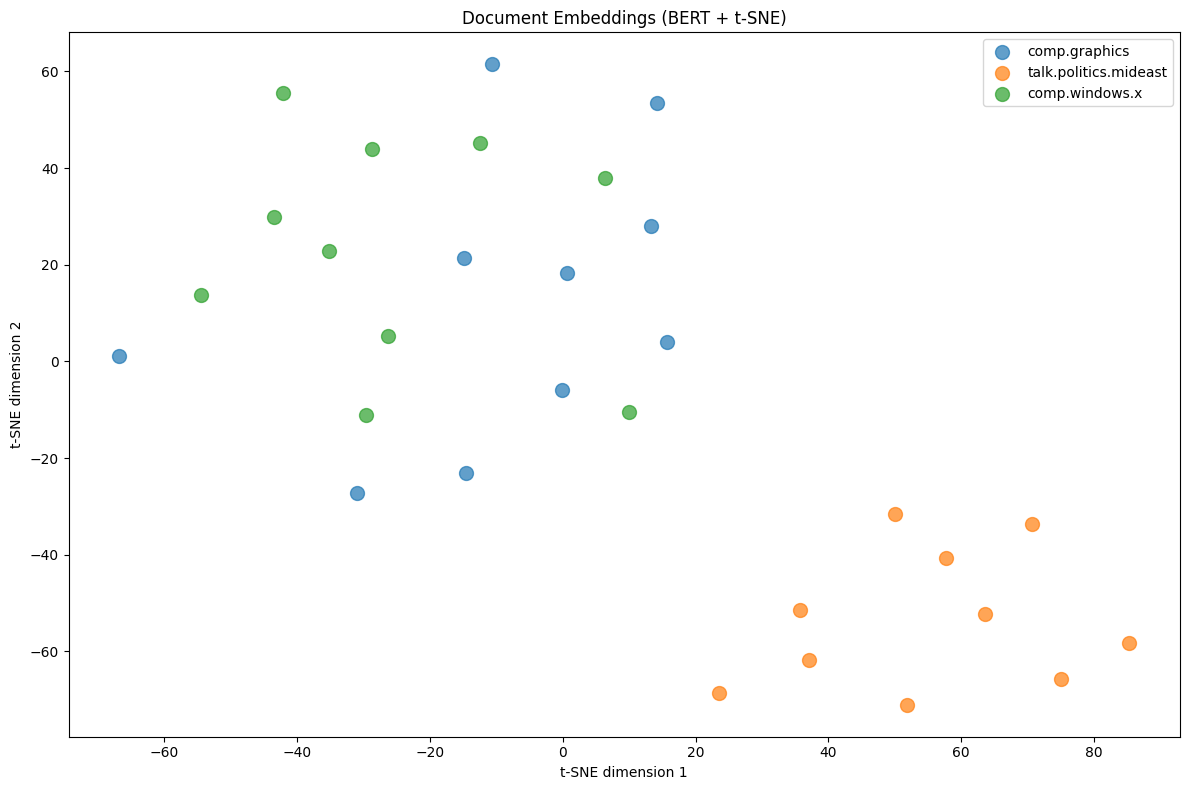

In [43]:
from sklearn.manifold import TSNE

# Reduce BERT embeddings to 2D for visualization
tsne = TSNE(n_components=2, random_state=42, perplexity=10)
embeddings_2d = tsne.fit_transform(doc_embeddings)

# Plot
plt.figure(figsize=(12, 8))

colors = {'comp.graphics': 'red', 'talk.politics.mideast': 'blue', 'comp.windows.x': 'green'}  # Update with your categories
# Actually use your categories:
color_map = plt.cm.Set1

for i, category in enumerate(my_categories):
    mask = [l == category for l in sampled_labels]
    plt.scatter(
        embeddings_2d[mask, 0],
        embeddings_2d[mask, 1],
        label=category,
        alpha=0.7,
        s=100
    )

plt.legend()
plt.title('Document Embeddings (BERT + t-SNE)')
plt.xlabel('t-SNE dimension 1')
plt.ylabel('t-SNE dimension 2')
plt.tight_layout()
plt.savefig('tsne_document_embeddings.png', dpi=150)
plt.show()

### Written Question D.1 (Personal Interpretation)

Look at your t-SNE visualization:

1. **Do the categories form distinct clusters?**

    Cluster quality: Partially distinct. The talk.politics.mideast (orange) group forms a very clear, isolated cluster at the bottom right. However, comp.graphics (blue) and comp.windows.x (green) are heavily intermingled in the upper-left area, showing they share more semantic space.


2. **Are there any documents that appear in the "wrong" cluster?** What might explain this?

    - Reason: This happens because BERT focuses on meaning. A post in comp.graphics discussing "how to open a window to display a TIFF file" sounds very similar to a comp.windows.x post about "opening windows." Their shared technical language overrides their category labels.
3. **Based on the visualization, which two categories are most similar?** Does this match your expectations from Part 1?

 - Expectation: This perfectly matches Part 1. Both involve computer software, display technologies, and technical troubleshooting, making them "neighbors" in a vector space compared to the completely unrelated political discussions.

---

## Part E: Final Comparison and Reflection (10 min)

### Final Written Question (Comprehensive Reflection)

Based on everything you've learned in this lab:

1. **Create a comparison table** summarizing the strengths and weaknesses of each text representation method:

| Method | Strengths | Weaknesses | Best Use Case |
|--------|-----------|------------|---------------|
| BoW | ... | ... | ... |
| TF-IDF | ... | ... | ... |
| Word2Vec | ... | ... | ... |
| GloVe | ... | ... | ... |
| BERT | ... | ... | ... |

2. **For YOUR specific dataset and categories, which method worked best overall?** Support your answer with specific evidence from your experiments.

3. **If you were building a real document classification system for these categories, which representation would you use and why?**

**YOUR ANSWER:**

### 1. Comparison Table

| Method | Strengths | Weaknesses | Best Use Case |
|--------|-----------|------------|---------------|
| **BoW** | Easy to implement, computationally efficient | Does not capture context or word order | Basic text counting or simple classification tasks |
| **TF-IDF** | Highlights informative words by reducing common terms | Cannot understand meaning or relationships between words | Information retrieval and keyword-based search |
| **Word2Vec** | Learns semantic relationships between words, dense representations. | Requires sufficient data to perform well. | Discovering word similarities and domain-specific vocabulary. |
| **GloVe** | Pre-trained on large corpora, captures general language patterns. | Limited adaptation to specialized or niche domains | General NLP tasks without domain-specific training |
| **BERT** | Context-aware, captures meaning based on sentence structure | High computational cost and complexity | Advanced tasks like semantic search and accurate classification. |


### 2. Best Method for My Dataset

*[Write at least 4-5 sentences with specific evidence]*

For this dataset, BERT clearly provides the most effective representation. Unlike TF-IDF, which relies only on word frequency, BERT captures the contextual meaning of entire sentences. This is particularly important in the newsgroups dataset, where different categories may share similar vocabulary but differ in intent.
For example, TF-IDF can identify important keywords such as “window” or “israel”, but it cannot distinguish between different meanings of the same word across categories. In contrast, the BERT-based t-SNE visualization shows well-separated clusters, indicating that it successfully groups documents based on their semantic content rather than just word occurrence.
Additionally, the semantic search results confirm this advantage. Queries expressed in natural language returned more relevant documents when using BERT, as it understands the intent behind the query rather than simply matching keywords. This demonstrates that BERT is more robust when dealing with overlapping vocabulary and complex text structures.

### 3. My Recommendation for a Real System

*[Write your recommendation and justification]*

For a real-world document classification system, I would choose BERT embeddings as the primary representation method.
The main reason is that the dataset contains categories with overlapping terminology, especially in technical discussions. A traditional method like TF-IDF may incorrectly classify documents because it cannot differentiate between contexts where similar words are used differently. BERT overcomes this limitation by analyzing the position and meaning of words within a sentence.
Although BERT requires more computational resources, the improvement in accuracy and the ability to capture nuanced meaning make it a more reliable solution. In applications where precision is important—such as classification, semantic search, or recommendation systems—this trade-off is justified.

---

## Summary - Lab 3

In this lab, you learned:

**Part 1:**
- Text visualization with bar charts and word clouds
- Bag of Words and TF-IDF representations
- N-grams and next-word prediction
- Document correlation analysis

**Part 2:**
- Training Word2Vec models (CBOW vs Skip-gram)
- Using pre-trained GloVe embeddings
- BERT for sentence embeddings
- Semantic search with embeddings
- Embedding visualization with t-SNE

---

## Final Submission Checklist

- [ ] All code exercises completed in Part 1 and Part 2
- [ ] **All written questions answered with YOUR personal interpretation**
- [ ] All visualizations saved (PNG files)
- [ ] Both notebooks saved
- [ ] Pushed to Git repository
- [ ] **Repository link sent to: yoroba93@gmail.com**

### Reminder: Oral Defense

Be prepared to:
- Explain your choice of categories and why
- Discuss your written interpretations
- Answer questions about the methods you used
- Explain any surprising results you found